Import Required Libraries

In [2]:
import numpy as np
import pandas as pd


Load EDA Processed Dataset

In [3]:
dp=pd.read_csv("fitness_classes_EDA.csv")

In [5]:
dp

,ActivitySiteID,ActivityDescription,BookingEndDate,BookingStartTime,MaxBookees,Number Booked,Price (INR),Month,Day,Hour,TimeSlot,Occupancy Rate,Revenue
0,BRP,20:20:20 9.30-10.30am,01-06-18,01-01-00 9:30,35,28,499,June,Friday,9,Morning,80.000000,13972
1,BRP,20:20:20 9.30-10.30am,08-06-18,01-01-00 9:30,35,35,499,June,Friday,9,Morning,100.000000,17465
2,BRP,20:20:20 9.30-10.30am,15-06-18,01-01-00 9:30,35,31,499,June,Friday,9,Morning,88.571429,15469
3,BRP,20:20:20 9.30-10.30am,22-06-18,01-01-00 9:30,35,32,499,June,Friday,9,Morning,91.428571,15968
4,BRP,20:20:20 9.30-10.30am,29-06-18,01-01-00 9:30,35,19,499,June,Friday,9,Morning,54.285714,9481
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3284,NBL,Zumba Gold 12.45-1.45pm,01-05-18,01-01-00 12:45,60,47,1999,May,Tuesday,12,Afternoon,78.333333,93953
3285,NBL,Zumba Gold 12.45-1.45pm,08-05-18,01-01-00 12:45,60,42,1999,May,Tuesday,12,Afternoon,70.000000,83958
3286,NBL,Zumba Gold 12.45-1.45pm,15-05-18,01-01-00 12:45,60,38,1999,May,Tuesday,12,Afternoon,63.333333,75962
3287,NBL,Zumba Gold 12.45-1.45pm,22-05-18,01-01-00 12:45,60,39,1999,May,Tuesday,12,Afternoon,65.000000,77961


Premium Classes Selection

In [7]:
dp.groupby("ActivityDescription")["Occupancy Rate"].mean().sort_values(ascending=False).head(10)

ActivityDescription
Aquafit  7.00-8.00pm      290.833333
Body Combat 11-12pm       100.000000
Pilates 9.30-10.30am       96.955128
Zumba 6.15-7.15pm          96.615385
Step 6-7pm                 96.153846
Pilates 9.00-9.50am        96.000000
Aqua Fit 11.15-12.00       95.428571
Aquafit 6.00-7.00pm        94.945055
Aquafit  6.00-7.00pm       94.285714
Pilates   9.00-10.00am     94.153846
Name: Occupancy Rate, dtype: float64

Observation

Highest average occupancy classes:

Body Combat 11-12pm
Pilates 9.30-10.30am
Zumba 6.15-7.15pm
Step 6-7pm
Pilates 9.00-9.50am
Business Insight

These classes are consistently filled with customers, indicating strong demand.

Premium Classes → +5%

Time Slot Pricing Rule

In [9]:
dp.groupby("TimeSlot")["Revenue"].sum().sort_values(ascending=False)

TimeSlot
Morning      43216074
Evening      38080314
Afternoon    18037407
Name: Revenue, dtype: int64

Morning classes generate the highest revenue, while afternoon classes have comparatively lower demand.

Morning → +3%
Evening → +2%
Afternoon → -3%

Reason:
Higher demand time slots receive a small premium, while low-demand slots receive a small discount to encourage bookings.

Day-wise Pricing Rule

In [13]:
dp.groupby("Day")["Number Booked"].sum().sort_values(ascending=False)

Day
Tuesday      12097
Wednesday    10737
Monday        9253
Thursday      8777
Friday        7294
Saturday      4766
Sunday        3281
Name: Number Booked, dtype: int64

Tuesday and Wednesday consistently attract more customers.
Sunday experiences comparatively lower demand.

Tuesday → +3%
Wednesday → +2%
Sunday → -3%

Reason:
Peak booking days can support premium pricing, while discounts on low-demand days may increase customer participation.

Location Pricing Rule

In [21]:
print(dp.groupby("ActivitySiteID")["Revenue"].sum().sort_values(ascending=False))
print(dp.groupby("ActivitySiteID")["Occupancy Rate"].mean().sort_values(ascending=False))

ActivitySiteID
HXP    23212909
BRP    22744232
SBP    20245003
NBL    19724207
TSC    13407444
Name: Revenue, dtype: int64
ActivitySiteID
HXP    67.039792
BRP    65.686120
SBP    58.379249
TSC    51.947210
NBL    34.562202
Name: Occupancy Rate, dtype: float64


HXP and BRP consistently perform better in both revenue generation and occupancy.
Other locations do not provide sufficient evidence for premium pricing.

HXP → +3%
BRP → +2%
SBP → No Change
NBL → No Change
TSC → No Change

Reason:
Price increases were applied only to locations with consistently high demand and revenue.

Occupancy Based Pricing Rule

In [27]:
dp["Occupancy Rate"].describe()


count    3289.000000
mean       57.155395
std        31.844422
min         1.666667
25%        34.285714
50%        55.000000
75%        80.000000
max       516.666667
Name: Occupancy Rate, dtype: float64

From the occupancy analysis:

The average occupancy was 57.16%, indicating moderate overall demand.
Classes with occupancy ≥ 90% were considered high-demand classes because they were almost fully booked.
Classes with occupancy < 40% were considered low-demand classes because many seats remained vacant.
Therefore, these thresholds were used to define the occupancy-based pricing rules.

Occupancy Rate ≥ 90%  → Increase Price by 5%
Occupancy Rate < 40%  → Decrease Price by 5%

why this rule:
≥ 90%: The class is nearly full, so a small premium can increase revenue without significantly affecting demand.
< 40%: The class has low utilisation, so a small discount can encourage more bookings and improve occupancy.

In [ ]:
"""Note:
A few occupancy values exceeded 100%, 
indicating possible overbooking or data quality issues.
Since these values could not be confirmed as invalid without business context, 
they were retained in the dataset but excluded while identifying premium classes for pricing decisions."""

Dynamic Pricing Algorithm.

Description:

Based on insights obtained from Exploratory Data Analysis, a rule-based dynamic pricing algorithm was developed. The algorithm adjusts the original class price using five business rules:

Occupancy Rate
Time Slot
Day-wise Demand
Premium Class Popularity
Location Performance

The price adjustments were intentionally limited to 2–5% because the price elasticity analysis showed only a weak negative relationship between price and demand.

Dynamic Pricing Algorithm

In [28]:
# Premium Classes (High Occupancy)
premium_classes = [
    "Body Combat 11-12pm",
    "Pilates 9.30-10.30am",
    "Zumba 6.15-7.15pm",
    "Step 6-7pm",
    "Pilates 9.00-9.50am"
]

def dynamic_pricing(row):

    price = row["Price (INR)"]

    # Rule 1: Occupancy Based Pricing
    if row["Occupancy Rate"] >= 90:
        price *= 1.05
    elif row["Occupancy Rate"] < 40:
        price *= 0.95

    # Rule 2: Time Slot Based Pricing
    if row["TimeSlot"] == "Morning":
        price *= 1.03
    elif row["TimeSlot"] == "Evening":
        price *= 1.02
    elif row["TimeSlot"] == "Afternoon":
        price *= 0.97

    # Rule 3: Day Based Pricing
    if row["Day"] == "Tuesday":
        price *= 1.03
    elif row["Day"] == "Wednesday":
        price *= 1.02
    elif row["Day"] == "Sunday":
        price *= 0.97

    # Rule 4: Premium Class Pricing
    if row["ActivityDescription"] in premium_classes:
        price *= 1.05

    # Rule 5: Location Based Pricing
    if row["ActivitySiteID"] == "HXP":
        price *= 1.03
    elif row["ActivitySiteID"] == "BRP":
        price *= 1.02

    return round(price)

# Apply Dynamic Pricing
dp["Dynamic Price"] = dp.apply(dynamic_pricing, axis=1)

Apply Pricing

In [29]:
dp["Dynamic Price"] = dp.apply(dynamic_pricing, axis=1)

In [30]:
original_revenue = (dp["Price (INR)"] * dp["Number Booked"]).sum()

dynamic_revenue = (dp["Dynamic Price"] * dp["Number Booked"]).sum()

increase = dynamic_revenue - original_revenue

percentage = (increase / original_revenue) * 100

print(f"Original Revenue : ₹{original_revenue:,.0f}")
print(f"Dynamic Revenue : ₹{dynamic_revenue:,.0f}")
print(f"Revenue Increase : ₹{increase:,.0f}")
print(f"Percentage Increase : {percentage:.2f}%")

Original Revenue : ₹99,333,795
Dynamic Revenue : ₹103,230,066
Revenue Increase : ₹3,896,271
Percentage Increase : 3.92%


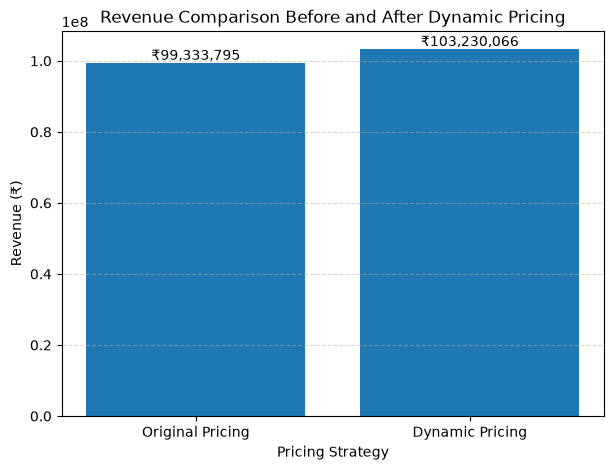

In [31]:
import matplotlib.pyplot as plt

# Revenue Values
original_revenue = (dp["Price (INR)"] * dp["Number Booked"]).sum()
dynamic_revenue = (dp["Dynamic Price"] * dp["Number Booked"]).sum()

# Data for plotting
labels = ["Original Pricing", "Dynamic Pricing"]
revenues = [original_revenue, dynamic_revenue]

# Plot
plt.figure(figsize=(7,5))
bars = plt.bar(labels, revenues)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"₹{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Revenue Comparison Before and After Dynamic Pricing")
plt.xlabel("Pricing Strategy")
plt.ylabel("Revenue (₹)")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

 Conclusion

The dynamic pricing strategy was successfully developed using insights obtained from Exploratory Data Analysis.

The pricing algorithm considered:

Occupancy Rate
Time Slot
Day-wise Demand
Premium Classes
Location Performance

The proposed strategy increased the total revenue from ₹99.33 Million to ₹103.23 Million, resulting in a 3.92% improvement while maintaining customer-friendly price adjustments.